# Principal Component Analysis (PCA)

This notebook demonstrates PCA using several visual tools.

We will examine:

1. Scree plots
2. Cumulative variance plots
3. PCA scatter plots
4. Biplots
5. Reconstruction using reduced dimensions

Datasets used:
- Iris (low dimensional visualization)
- Wine (interpretable loadings)
- Digits (high dimensional reduction)


## Import Libraries

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Example 1 — Iris Dataset

Goal: visualize PCA in low dimensions.

In [37]:
iris = load_iris()
X = iris.data
y = iris.target

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

## Scree Plot

The scree plot displays eigenvalues of the covariance matrix.

How to interpret:

- Each point corresponds to a principal component
- Larger eigenvalues mean more variance explained
- The "elbow" indicates where additional components contribute little new information
- Typically we retain components before the elbow

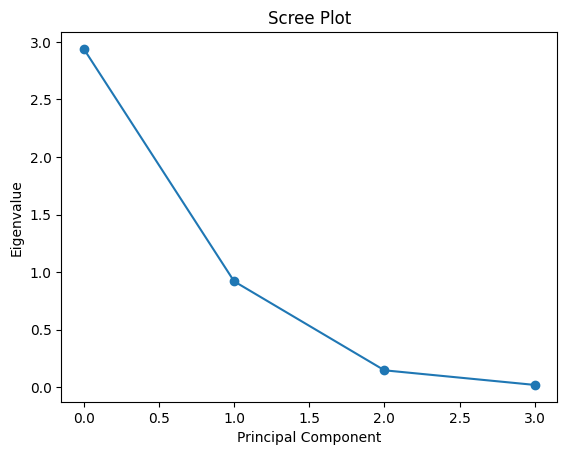

In [38]:
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

## Cumulative Variance Plot

This plot shows how much total variance is captured as we add components.

Interpretation:

- If the curve rises quickly, the data are low dimensional
- Often we choose the smallest k such that

variance explained ≥ 80–95%

[0.72962445 0.95813207 0.99482129 1.        ]


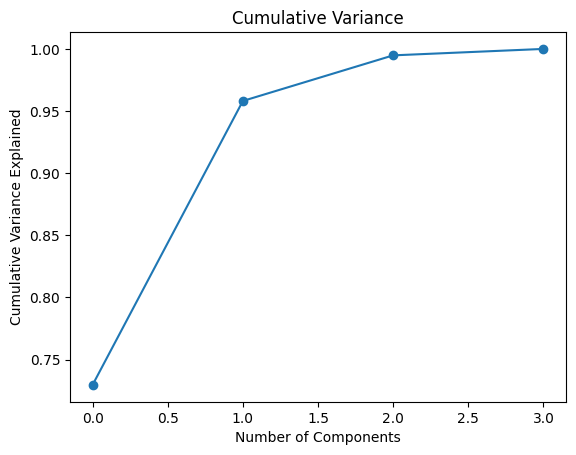

In [39]:
cumvar = np.cumsum(pca.explained_variance_ratio_)

print(cumvar)

plt.plot(cumvar, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance')
plt.show()

## PCA Scatter Plot

Plotting observations using the first two principal components.

Interpretation:

- Points close together represent similar observations
- Separation between groups indicates structure in the data
- PCA often reveals clusters even without labels

## PCA Biplot

A biplot shows:

- observations (points)
- variable directions (arrows)

How to interpret:

Arrow length:
- longer arrows indicate variables strongly contributing to PCs

Angle between arrows:
- small angle → high positive correlation
- 180 degrees → negative correlation
- 90 degrees → near zero correlation

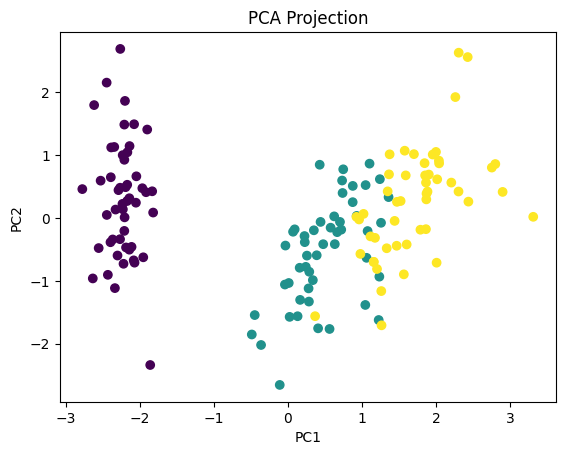

In [40]:
plt.scatter(Z[:,0], Z[:,1], c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()

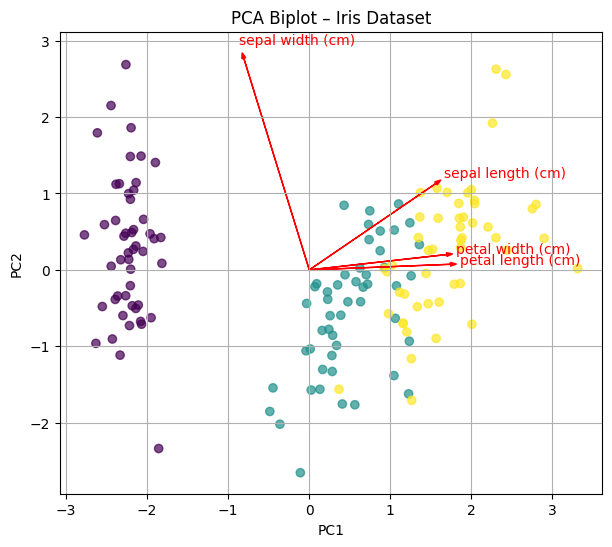

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# load data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

# loadings
loadings = pca.components_.T

# plot PCA scores
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=y, cmap='viridis', alpha=0.7)

# plot variable vectors
for i in range(len(feature_names)):
    plt.arrow(0, 0,
              loadings[i,0]*3,
              loadings[i,1]*3,
              color='red',
              head_width=0.05)
    plt.text(loadings[i,0]*3.2,
             loadings[i,1]*3.2,
             feature_names[i],
             color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot – Iris Dataset")
plt.grid()
plt.show()

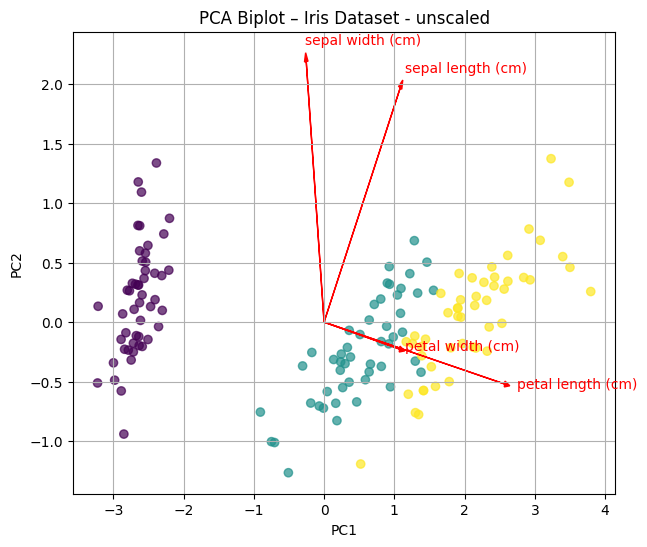

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# load data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# unscaled

# PCA
pca = PCA(n_components=2)
Z = pca.fit_transform(X)

# loadings
loadings = pca.components_.T

# plot PCA scores
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], c=y, cmap='viridis', alpha=0.7)

# plot variable vectors
for i in range(len(feature_names)):
    plt.arrow(0, 0,
              loadings[i,0]*3,
              loadings[i,1]*3,
              color='red',
              head_width=0.05)
    plt.text(loadings[i,0]*3.2,
             loadings[i,1]*3.2,
             feature_names[i],
             color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot – Iris Dataset - unscaled")
plt.grid()
plt.show()

# Example 2 — Exam Dataset


In [43]:
from google.colab import files
files.upload()

{}

Shape: (88, 5)
   mec  vec  alg  ana  sta
0   77   82   67   67   81
1   63   78   80   70   81
2   75   73   71   66   81
3   55   72   63   70   68
4   63   63   65   70   63


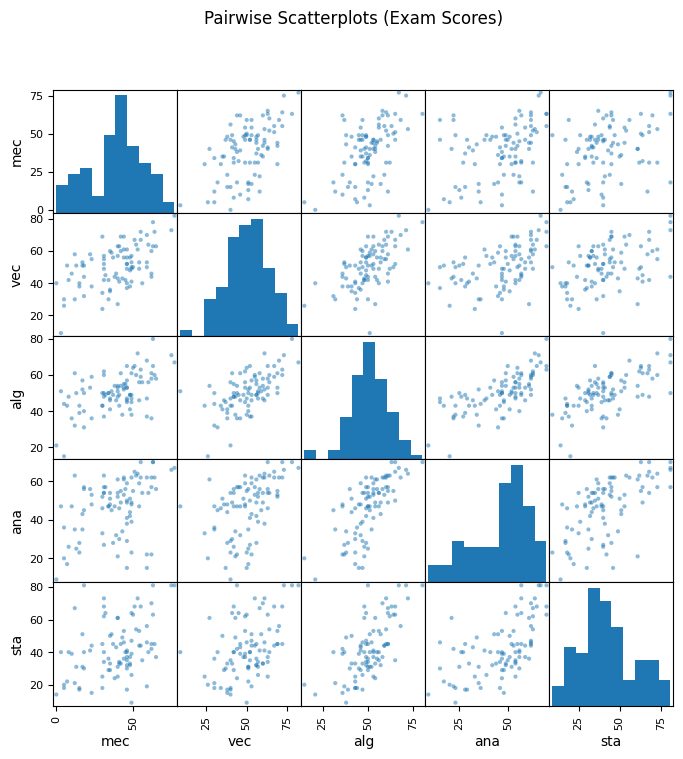


Correlation matrix
          mec       vec       alg       ana       sta
mec  1.000000  0.553405  0.546751  0.409392  0.389099
vec  0.553405  1.000000  0.609645  0.485081  0.436449
alg  0.546751  0.609645  1.000000  0.710806  0.664736
ana  0.409392  0.485081  0.710806  1.000000  0.607174
sta  0.389099  0.436449  0.664736  0.607174  1.000000

Explained variance ratio:
[0.63619603 0.14791437 0.08899303 0.07757848 0.0493181 ]


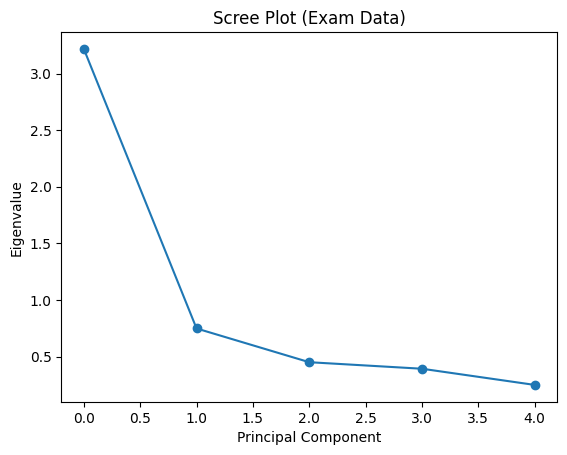

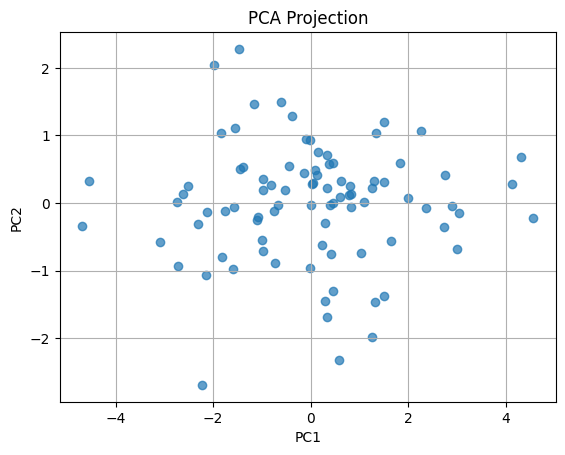

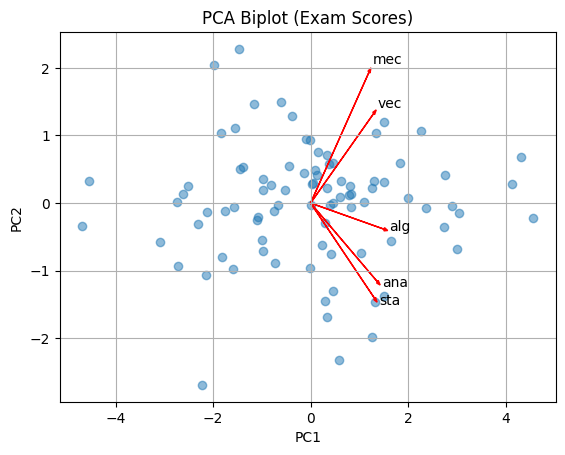


Variable contributions (loadings):
          PC1       PC2
mec  0.399605  0.645458
vec  0.431419  0.441505
alg  0.503282 -0.129068
ana  0.456994 -0.387906
sta  0.438244 -0.470454

Absolute contributions (magnitude):
          PC1       PC2
alg  0.503282  0.129068
ana  0.456994  0.387906
sta  0.438244  0.470454
vec  0.431419  0.441505
mec  0.399605  0.645458

Variance explained:
PC1: 0.6361960298321695
PC2: 0.1479143683042826


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---- Load dataset ----
data = pd.read_csv("scor.csv")

print("Shape:", data.shape)
print(data.head())

# ---- Pairwise scatterplots ----
pd.plotting.scatter_matrix(data, figsize=(8,8))
plt.suptitle("Pairwise Scatterplots (Exam Scores)")
plt.show()

print("\nCorrelation matrix")
print(data.corr())

# ---- Standardize ----
X = StandardScaler().fit_transform(data)

# ---- PCA ----
pca = PCA()
Z = pca.fit_transform(X)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

# ---- Scree plot ----
plt.figure()
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot (Exam Data)")
plt.show()

# ---- PCA scatter ----
plt.figure()
plt.scatter(Z[:,0], Z[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.grid()
plt.show()

# ---- PCA biplot ----
loadings = pca.components_.T

plt.figure()
plt.scatter(Z[:,0], Z[:,1], alpha=0.5)

for i, feature in enumerate(data.columns):
    plt.arrow(0, 0, loadings[i,0]*3, loadings[i,1]*3, color='red', head_width=0.05)
    plt.text(loadings[i,0]*3.2, loadings[i,1]*3.2, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot (Exam Scores)")
plt.grid()
plt.show()

# ---- Print variable contributions for PC1 and PC2 ----
loadings = pd.DataFrame(
    pca.components_.T[:, :2],   # take first two PCs
    columns=["PC1", "PC2"],
    index=data.columns
)

print("\nVariable contributions (loadings):")
print(loadings)

print("\nAbsolute contributions (magnitude):")
print(loadings.abs().sort_values(by="PC1", ascending=False))

print("\nVariance explained:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

# Example 3 — Decathlon Dataset

Goal: dimensionality reduction for high dimensional data.

In [45]:
from google.colab import files
files.upload()

Saving decathlon.csv to decathlon (1).csv


{'decathlon (1).csv': b'"100m","Long.jump","Shot.put","High.jump","400m","110m.hurdle","Discus","Pole.vault","Javeline","1500m","Rank","Points","Competition"\r\n11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,"Decastar"\r\n10.76,7.4,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,"Decastar"\r\n11.02,7.3,14.77,2.04,48.37,14.09,48.95,4.92,50.31,300.2,3,8099,"Decastar"\r\n11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,"Decastar"\r\n11.34,7.09,15.19,2.1,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,"Decastar"\r\n11.11,7.6,14.31,1.98,48.68,14.23,41.1,4.92,51.77,278.1,6,8030,"Decastar"\r\n11.13,7.3,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268,7,8004,"Decastar"\r\n10.83,7.31,13.76,2.13,49.91,14.38,44.41,4.42,56.37,285.1,8,7995,"Decastar"\r\n11.64,6.81,14.57,1.95,50.14,14.93,47.6,4.92,52.33,262.1,9,7802,"Decastar"\r\n11.37,7.56,14.41,1.86,51.1,15.06,44.99,4.82,57.19,285.1,10,7733,"Decastar"\r\n11.33,6.97,14.09,1.95,49.48,14.48,42.1,4.72,55.4,282,11,7708,"Decast

Dataset shape: (41, 13)
    100m  Long.jump  Shot.put  High.jump   400m  110m.hurdle  Discus  \
0  11.04       7.58     14.83       2.07  49.81        14.69   43.75   
1  10.76       7.40     14.26       1.86  49.37        14.05   50.72   
2  11.02       7.30     14.77       2.04  48.37        14.09   48.95   
3  11.02       7.23     14.25       1.92  48.93        14.99   40.87   
4  11.34       7.09     15.19       2.10  50.42        15.31   46.26   

   Pole.vault  Javeline  1500m  Rank  Points Competition  
0        5.02     63.19  291.7     1    8217    Decastar  
1        4.92     60.15  301.5     2    8122    Decastar  
2        4.92     50.31  300.2     3    8099    Decastar  
3        5.32     62.77  280.1     4    8067    Decastar  
4        4.72     63.44  276.4     5    8036    Decastar  

Explained variance ratio:
[0.32719055 0.1737131  0.14049167 0.10568504 0.06847735 0.05992687
 0.04512353 0.03968766 0.02148149 0.01822275]


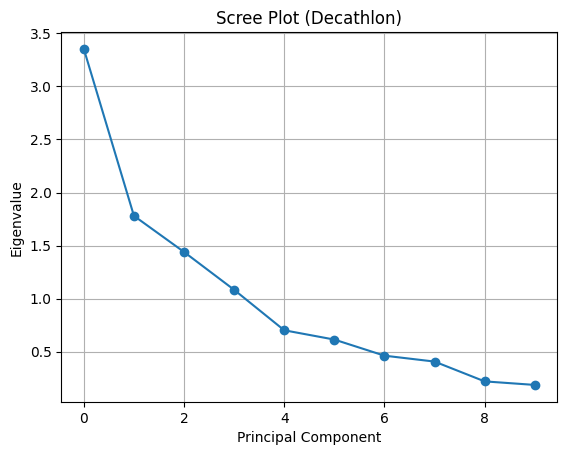

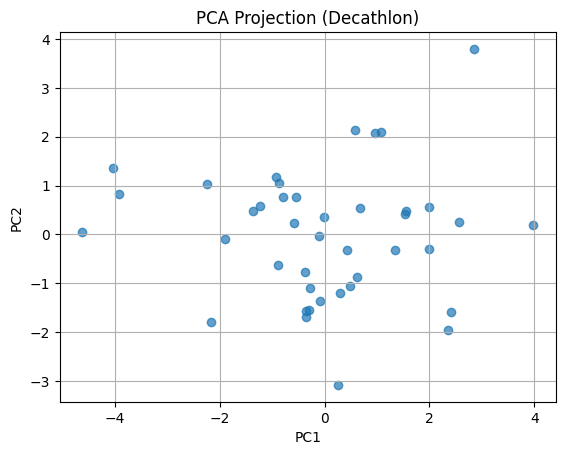


Variable contributions (loadings):
                  PC1       PC2
100m         0.428296  0.141989
Long.jump   -0.410152 -0.262079
Shot.put    -0.344144  0.453947
High.jump   -0.316194  0.265776
400m         0.375716  0.432046
110m.hurdle  0.412554  0.173591
Discus      -0.305426  0.460024
Pole.vault  -0.027831 -0.136841
Javeline    -0.153198  0.240507
1500m        0.032107  0.359805


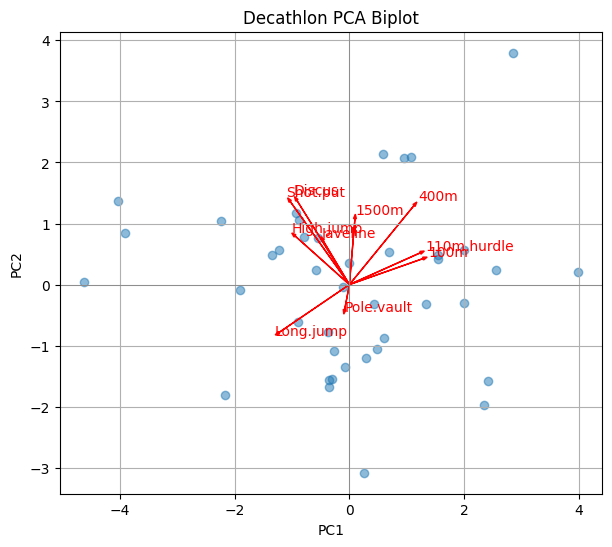

In [48]:
# PCA analysis for the Decathlon dataset (assumes decathlon.csv exported from R FactoMineR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---- Load dataset ----
data = pd.read_csv("decathlon.csv")

print("Dataset shape:", data.shape)
print(data.head())

# ---- Select the 10 decathlon event variables ----
X = data.iloc[:, :10]   # first 10 columns are events

# ---- Standardize ----
X_scaled = StandardScaler().fit_transform(X)

# ---- PCA ----
pca = PCA()
Z = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

# ---- Scree plot ----
plt.figure()
plt.plot(pca.explained_variance_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot (Decathlon)")
plt.grid()
plt.show()

# ---- PCA scatter plot ----
plt.figure()
plt.scatter(Z[:,0], Z[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Decathlon)")
plt.grid()
plt.show()

# ---- Variable loadings for PC1 and PC2 ----
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=["PC1","PC2"],
    index=X.columns
)

print("\nVariable contributions (loadings):")
print(loadings)

# ---- PCA Biplot ----
plt.figure(figsize=(7,6))
plt.scatter(Z[:,0], Z[:,1], alpha=0.5)

for i, var in enumerate(X.columns):
    plt.arrow(0,0,
              loadings.iloc[i,0]*3,
              loadings.iloc[i,1]*3,
              color='red',
              head_width=0.05)

    plt.text(loadings.iloc[i,0]*3.2,
             loadings.iloc[i,1]*3.2,
             var,
             color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decathlon PCA Biplot")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid()
plt.show()

In [47]:
# ---- Correlation of variables with PCs ----
corr_pc = pd.DataFrame(
    np.corrcoef(X_scaled.T, Z.T)[:X.shape[1], X.shape[1]:X.shape[1]+2],
    columns=["PC1","PC2"],
    index=X.columns
)

print("\nCorrelation of variables with PC1 and PC2")
print(corr_pc)

# ---- Identify dominant variables for each PC ----
print("\nVariables strongly associated with PC1")
print(corr_pc["PC1"].sort_values(ascending=False))

print("\nVariables strongly associated with PC2")
print(corr_pc["PC2"].sort_values(ascending=False))

# ---- Correlation matrix between events ----
print("\nCorrelation matrix between events")
print(X.corr())


Correlation of variables with PC1 and PC2
                  PC1       PC2
100m         0.774720  0.187142
Long.jump   -0.741900 -0.345421
Shot.put    -0.622503  0.598303
High.jump   -0.571945  0.350294
400m         0.679610  0.569438
110m.hurdle  0.746245  0.228793
Discus      -0.552467  0.606313
Pole.vault  -0.050342 -0.180357
Javeline    -0.277111  0.316989
1500m        0.058077  0.474224

Variables strongly associated with PC1
100m           0.774720
110m.hurdle    0.746245
400m           0.679610
1500m          0.058077
Pole.vault    -0.050342
Javeline      -0.277111
Discus        -0.552467
High.jump     -0.571945
Shot.put      -0.622503
Long.jump     -0.741900
Name: PC1, dtype: float64

Variables strongly associated with PC2
Discus         0.606313
Shot.put       0.598303
400m           0.569438
1500m          0.474224
High.jump      0.350294
Javeline       0.316989
110m.hurdle    0.228793
100m           0.187142
Pole.vault    -0.180357
Long.jump     -0.345421
Name: PC2, dtype: f

First PC is more in the direction of track events than in the direction of field events (identifying groups)

The variables Discus, Shot.put and High.jump are not much correlated to the variables X100m, X400m, X110m.hurdle and Long.jump. This means that strength is not much correlated to speed.

Track events are nearly in one direction and similar magnitude and similar is true for field events. They also seem orthogonal to each other.